In [1]:
import os
import sys
sys.path.insert(0, os.path.abspath('../../'))
from src.analysis.metrics import *
from src.modeling.feature_engineering import *

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
from statsmodels.tsa.holtwinters import Holt

##### **It is assumed that the time series are stationary**

In [2]:
# Restaurant data with the ingredients to predict
daily_consumption_df = pd.read_csv('../../data/restaurant_daily_consumption.csv', index_col=0, parse_dates=True)
#daily_consumption_df = daily_consumption_df[['Sugar', 'Clove']]
display(daily_consumption_df)

output_size = daily_consumption_df.columns.size
target_columns = daily_consumption_df.columns

,Salt,Butter,Clove,Paprika
Date,,,,
2019-01-01,153.239057,321.711470,0.105100,3.138373
2019-01-02,99.513072,209.820995,0.046643,1.350212
2019-01-03,117.875365,237.576920,0.063806,2.281810
2019-01-04,96.942893,174.787086,0.052618,1.704081
2019-01-05,202.000220,419.131996,0.141272,4.466417
...,...,...,...,...
2019-06-26,114.674757,235.888240,0.073788,2.196996
2019-06-27,210.018279,426.500333,0.120884,3.584728
2019-06-28,174.151584,322.933919,0.092912,3.710093


##### Apply Log Transformation

In [3]:
# Apply log transformation to numerical features
df_log_transformed = daily_consumption_df.copy()
df_log_transformed = np.log1p(daily_consumption_df) # Apply log1p (log(x + 1))
#display(df_log_transformed)

# Check correlation
corr_matrix = df_log_transformed.corr()
display(corr_matrix)

,Salt,Butter,Clove,Paprika
Salt,1.000000,0.991983,0.893016,0.925415
Butter,0.991983,1.000000,0.888867,0.922138
Clove,0.893016,0.888867,1.000000,0.833260
Paprika,0.925415,0.922138,0.833260,1.000000


##### Run the ADF test and identify non-stationary series

In [4]:
# List to store the ADF test results and non stationary series
results = []
non_stationary_columns = []

# Apply the check for each ingredient
for col in df_log_transformed.columns:
    adf_statistic, p_value, isStationary = check_stationarity(df_log_transformed[col])
    
    # Create a dictionary for each result
    result_dict = {
        'Ingredient': col,
        'ADF Statistic': adf_statistic,
        'p-value': p_value,
        'isStationary': isStationary,
        'Stationarity Conclusion': "Series is stationary" if isStationary else "Series is not stationary"
    }
    
    # Append the dictionary to the results list
    results.append(result_dict)

    # Store non-stationary columns
    if not isStationary:
        non_stationary_columns.append(col)

# Convert the list of dictionaries to a DataFrame to display ADF results
adf_results = pd.DataFrame(results)
display(adf_results)

,Ingredient,ADF Statistic,p-value,isStationary,Stationarity Conclusion
0,Salt,-2.315402,0.167049,False,Series is not stationary
1,Butter,-2.258592,0.185671,False,Series is not stationary
2,Clove,-3.659501,0.004720,True,Series is stationary
3,Paprika,-3.571942,0.006321,True,Series is stationary


##### Making time series stationary

In [5]:
# Set frequency to daily
df_log_transformed = df_log_transformed.asfreq('D')

# Dictionary to store residuals and trends for each ingredient
residuals_dict = {}
trends_dict = {}

# Apply smoothing level to non-stationary series
for col_name in target_columns:
    # Extract the ingredient's time series
    ingredient_series = df_log_transformed[col_name]

    if col_name in non_stationary_columns:
        # Fit the Holt model to the series
        model = Holt(ingredient_series)
        results = model.fit(smoothing_level=1.5)

        # Extract the fitted trend
        trend = results.fittedvalues

        # Calculate the residuals (original - trend)
        residual = ingredient_series - trend
        
        # Store the residuals and trends in their respective dictionaries
        residuals_dict[col_name] = residual
        trends_dict[col_name] = trend
    else: 
        # If the series is stationary, store it directly in the residuals
        residuals_dict[col_name] = ingredient_series

# Combine the residuals and trends into DataFrames
df_stationary_data = pd.DataFrame(residuals_dict)
df_trend_data = pd.DataFrame(trends_dict)

# Display the final DataFrames
display(df_stationary_data)
display(df_trend_data)

,Salt,Butter,Clove,Paprika
Date,,,,
2019-01-01,0.428216,0.425749,0.099936,1.420303
2019-01-02,-0.223071,-0.221610,0.045588,0.854505
2019-01-03,0.703245,0.656048,0.061853,1.188395
2019-01-04,-0.136111,-0.225342,0.051280,0.994762
2019-01-05,1.208930,1.396690,0.132144,1.698623
...,...,...,...,...
2019-06-26,-0.453193,-0.284783,0.071192,1.162212
2019-06-27,0.872497,0.776701,0.114117,1.522731
2019-06-28,-0.596065,-0.637759,0.088846,1.549708


,Salt,Butter
Date,,
2019-01-01,4.610288,5.351009
2019-01-02,4.833358,5.572619
2019-01-03,4.074830,4.818644
2019-01-04,4.720495,5.394616
2019-01-05,4.104277,4.643879
...,...,...
2019-06-26,5.203975,5.752371
2019-06-27,4.479448,5.281254
2019-06-28,5.761717,6.418299


##### Apply Holdout Cross-Validation

In [6]:
# Determine the split index for training and testing data - Holdout cross-validation
train_size = int(len(df_stationary_data) * 0.80) 
df_train = df_stationary_data[:train_size]
df_test = df_stationary_data[train_size:]

##### Find the best lag feature to use

In [7]:
# Fit the VAR model
model = VAR(df_train)

# Select the best lag feature
select_lag_feature = model.select_order(maxlags=10)
select_lag_feature.summary()

,AIC,BIC,FPE,HQIC
0,-11.78,-11.69,7.685e-06,-11.74
1,-14.82,-14.39*,3.661e-07,-14.64
2,-15.09,-14.31,2.796e-07,-14.77
3,-15.26,-14.14,2.362e-07,-14.80*
4,-15.28,-13.81,2.333e-07,-14.68
5,-15.28,-13.46,2.343e-07,-14.54
6,-15.40,-13.23,2.096e-07,-14.52
7,-15.74*,-13.23,1.508e-07*,-14.72
8,-15.69,-12.84,1.591e-07,-14.53
9,-15.66,-12.46,1.677e-07,-14.36


##### Fit the model

In [8]:
# Fitting the model with the chosen lag order
var_results = model.fit(5, ic='aic')
var_results.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 30, Sep, 2024
Time:                     12:16:49
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                   -13.4824
Nobs:                     139.000    HQIC:                  -14.5351
Log likelihood:           355.346    FPE:                2.39085e-07
AIC:                     -15.2558    Det(Omega_mle):     1.36186e-07
--------------------------------------------------------------------
Results for equation Salt
                coefficient       std. error           t-stat            prob
-----------------------------------------------------------------------------
const              3.504623         0.444654            7.882           0.000
L1.Salt           -0.450303         0.520914           -0.864           0.387
L1.Butter         -0.550989         0.495178           -1.113           0

##### Obtain preditions and plot the final results

In [9]:
# Store predictions
predicted_df = pd.DataFrame(index=df_test.index, columns=df_test.columns)

# Use rolling forecast (recursive forecasting)
total_history = df_train.values.tolist()  # Initialize the history with the training data

for t in range(len(df_test)):
    # Convert history to a NumPy array before forecasting
    history_array = np.array(total_history)
    
    # Predict one step ahead
    prediction = var_results.forecast(y=history_array, steps=1)
    
    # Store the prediction
    predicted_df.iloc[t] = prediction[0]
    
    # Update history with the actual test value
    total_history.append(df_test.iloc[t].values)

# Convert all columns to numeric values
predicted_df = predicted_df.apply(pd.to_numeric, errors='coerce')

In [10]:
# Set forecast steps (equal to the length of the test set)
forecast_steps = len(df_test)

# Reverse the smoothing for forecasted values
df_forecast_without_smooth = reverse_smoothing(predicted_df, trends_dict, forecast_steps)
#display(df_forecast_without_smooth)

# # Reverse the smoothing for test values
df_test_without_smooth = reverse_smoothing(df_test, trends_dict, forecast_steps)
# #display(df_test_without_smooth)

# # Reverse the log transformation
df_test_forecasts = reverse_log(df_forecast_without_smooth)
df_test_actuals = reverse_log(df_test_without_smooth)

Salt RMSE: 101.16312041022428
Butter RMSE: 178.3629441240123
Clove RMSE: 0.057878902689984114
Paprika RMSE: 1.386782290265389


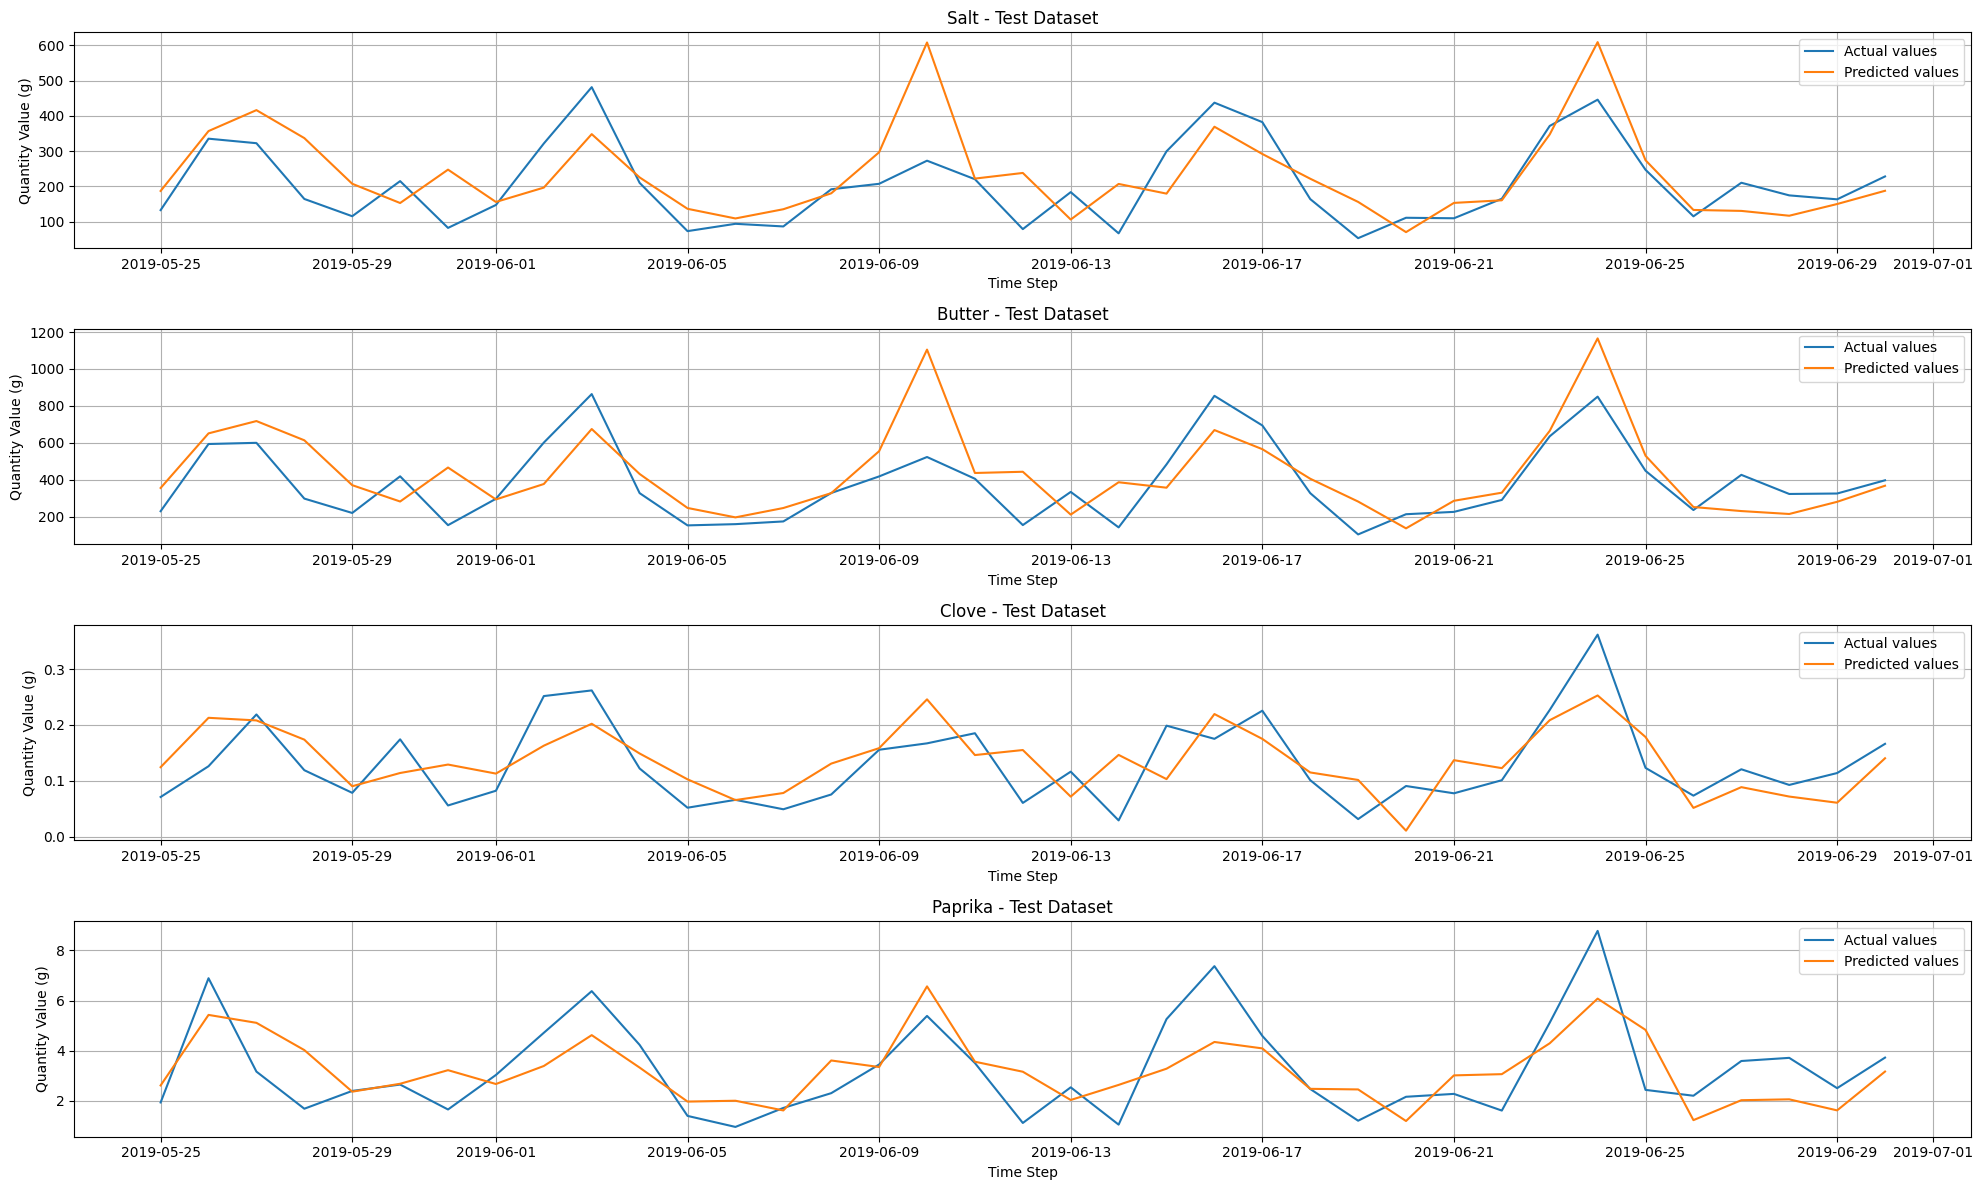

In [11]:
# # Initialize a dictionary to store RMSE values
rmse_dict = {}

# Calculate RMSE for each ingredient
for col in df_test.columns:
    # Extract actual and predicted values
    actual = df_test_actuals[col]
    predicted = df_test_forecasts[col]
    
    # Calculate Root Mean Squared Error (RMSE)
    rmse = calculate_rmse(actual, predicted)
    
    # Store RMSE in the dictionary
    rmse_dict[col] = rmse

# Print RMSE for each ingredient
for ingredient, rmse in rmse_dict.items():
    print(f'{ingredient} RMSE: {rmse}')

# Plotting the predicted vs actual values for each output
fig, axes = plt.subplots(output_size, 1, figsize=(20, 3 * output_size))

# Plot predicted vs. actual values for each ingredient
for idx, ingredient in enumerate(target_columns):
    #plt.figure(figsize=(25, 4))
    
    # # Plot actual values
    # plt.plot(df_test_actuals.index, df_test_actuals[col], label=f'Actual {col}')
    
    # # Plot predicted values
    # plt.plot(df_test_forecasts.index, df_test_forecasts[col], label=f'Predicted {col}')
    
    # # Add labels and title
    # plt.title(f'Actual vs. Predicted for {col}')
    # plt.xlabel('Time Step')
    # plt.ylabel('Quantity Value (g)')
    
    # plt.grid(True)
    # plt.legend()
    # plt.show()
    ax = axes[idx]
    ax.plot(df_test_actuals.index, df_test_actuals[ingredient], label='Actual values')
    ax.plot(df_test_actuals.index, df_test_forecasts[ingredient], label='Predicted values')
    ax.set_title(f'{ingredient} - Test Dataset')
    ax.set_xlabel('Time Step')
    ax.set_ylabel('Quantity Value (g)')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()